In [1]:
pip install numpy scipy matplotlib librosa

In [2]:
pip install pydub

In [3]:
from google.colab import files

uploaded = files.upload()

Saving my_voice.m4a to my_voice.m4a


In [4]:
import librosa
import soundfile as sf

input_file = list(uploaded.keys())[0]

# Load audio
signal, sr = librosa.load(input_file, sr=16000)

# Save as speech.wav
sf.write("speech.wav", signal, sr)

print("Converted to speech.wav successfully!")

/tmp/ipykernel_7013/328588523.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(input_file, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Converted to speech.wav successfully!


In [5]:
import os
print(os.listdir())

['.config', 'my_voice.m4a', 'speech.wav', 'sample_data']


/tmp/ipykernel_7013/2852086274.py:33: RuntimeWarning: invalid value encountered in scalar divide
  return first_k_energy / total_energy


DFT Energy (first 10 coeffs): nan
DCT Energy (first 10 coeffs): nan


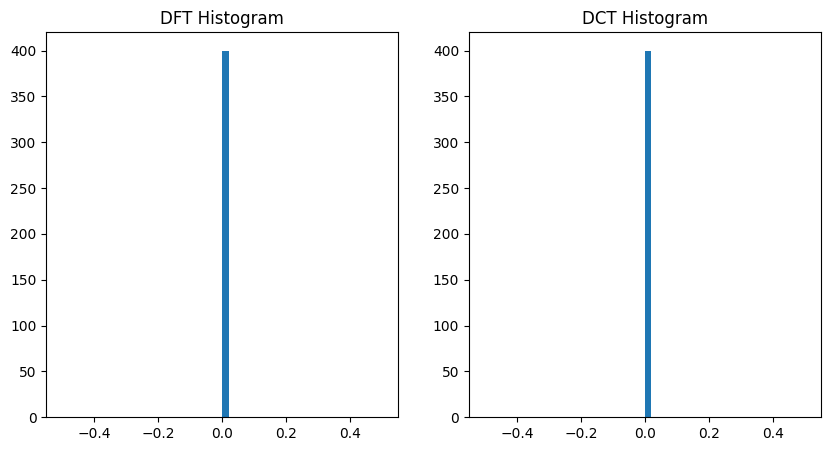

In [6]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.fftpack import dct
# 1. Load audio
def load_audio(path):
    signal, sr = librosa.load(path, sr=None)
    return signal, sr

# 2. Frame extraction (25 ms)
def get_frame(signal, sr, duration_ms=25):
    N = int(sr * duration_ms / 1000)
    frame = signal[:N]
    return frame

# 3. Apply Hamming window
def apply_window(frame):
    window = np.hamming(len(frame))
    return frame * window

# 4. Compute DFT
def compute_dft(frame):
    return np.abs(np.fft.fft(frame))

# 5. Compute DCT
def compute_dct(frame):
    return np.abs(dct(frame, norm='ortho'))

# 6. Energy comparison
def energy_compaction(coeffs, k=10):
    total_energy = np.sum(coeffs**2)
    first_k_energy = np.sum(coeffs[:k]**2)
    return first_k_energy / total_energy

# 7. Plot histogram
def plot_histogram(dft_vals, dct_vals):
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.hist(dft_vals, bins=50)
    plt.title("DFT Histogram")

    plt.subplot(1,2,2)
    plt.hist(dct_vals, bins=50)
    plt.title("DCT Histogram")

    plt.show()

# MAIN
audio_path = "speech.wav"
signal, sr = load_audio(audio_path)
frame = get_frame(signal, sr)
windowed = apply_window(frame)

dft_vals = compute_dft(windowed)
dct_vals = compute_dct(windowed)

# Energy comparison
dft_energy = energy_compaction(dft_vals)
dct_energy = energy_compaction(dct_vals)

print("DFT Energy (first 10 coeffs):", dft_energy)
print("DCT Energy (first 10 coeffs):", dct_energy)

plot_histogram(dft_vals, dct_vals)

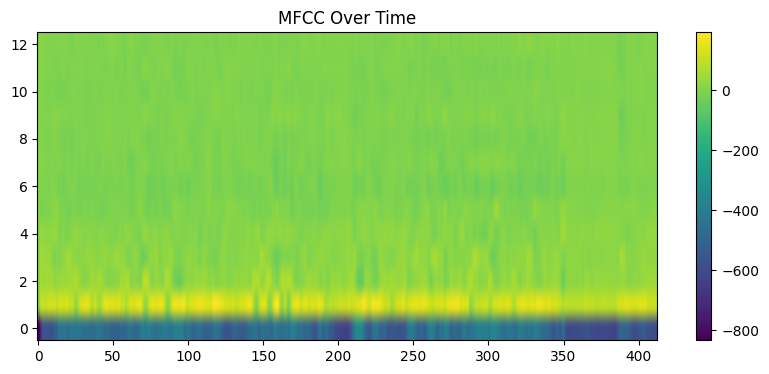

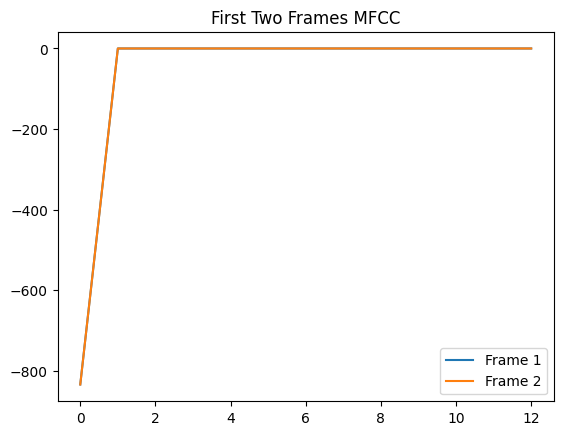

In [7]:
# 8. Compute MFCC
def compute_mfcc(signal, sr):
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    return mfccs

# 9. Plot MFCC
def plot_mfcc(mfccs):
    plt.figure(figsize=(10,4))
    plt.imshow(mfccs, aspect='auto', origin='lower')
    plt.title("MFCC Over Time")
    plt.colorbar()
    plt.show()

# 10. Plot first two frames
def plot_first_two_frames(mfccs):
    plt.plot(mfccs[:,0], label="Frame 1")
    plt.plot(mfccs[:,1], label="Frame 2")
    plt.legend()
    plt.title("First Two Frames MFCC")
    plt.show()

# RUN MFCC
mfccs = compute_mfcc(signal, sr)
plot_mfcc(mfccs)
plot_first_two_frames(mfccs)